Loading: /mnt/NAS-Ebanaru/Sasaki/MTsingleBeads/beads06um/20260716/beads06um/RDF.zarr
Loading: /mnt/NAS-Ebanaru/Sasaki/MTsingleBeads/beads06um/20260716/beads06um001/RDF.zarr
Loading: /mnt/NAS-Ebanaru/Sasaki/MTsingleBeads/beads06um/20260716/beads06um002/RDF.zarr
Loading: /mnt/NAS-Ebanaru/Sasaki/MTsingleBeads/beads06um/20260716/beads06um003/RDF.zarr
Loading: /mnt/NAS-Ebanaru/Sasaki/MTsingleBeads/beads1um/20260717/beads1um001_crop/RDF.zarr
Loading: /mnt/NAS-Ebanaru/Sasaki/MTsingleBeads/beads1um/20260717/beads1um002/RDF.zarr
Loading: /mnt/NAS-Ebanaru/Sasaki/MTsingleBeads/beads1um/20260717/beads1um003/RDF.zarr
Loading: /mnt/NAS-Ebanaru/Sasaki/MTsingleBeads/beads1um/20260717/beads1um_crop/RDF.zarr
Loading: /mnt/NAS-Ebanaru/Sasaki/MTsingleBeads/beads3um/20260708/beads3um/RDF.zarr
Loading: /mnt/NAS-Ebanaru/Sasaki/MTsingleBeads/beads3um/20260708/beads3um001/RDF.zarr
Loading: /mnt/NAS-Ebanaru/Sasaki/MTsingleBeads/beads3um/20260708/beads3um002/RDF.zarr
Loading: /mnt/NAS-Ebanaru/Sasaki/MTsingleBead

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

Loading: /mnt/NAS-Ebanaru/Sasaki/MTsingleBeads/beads20um/20260723/beads20um002/RDF.zarr


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

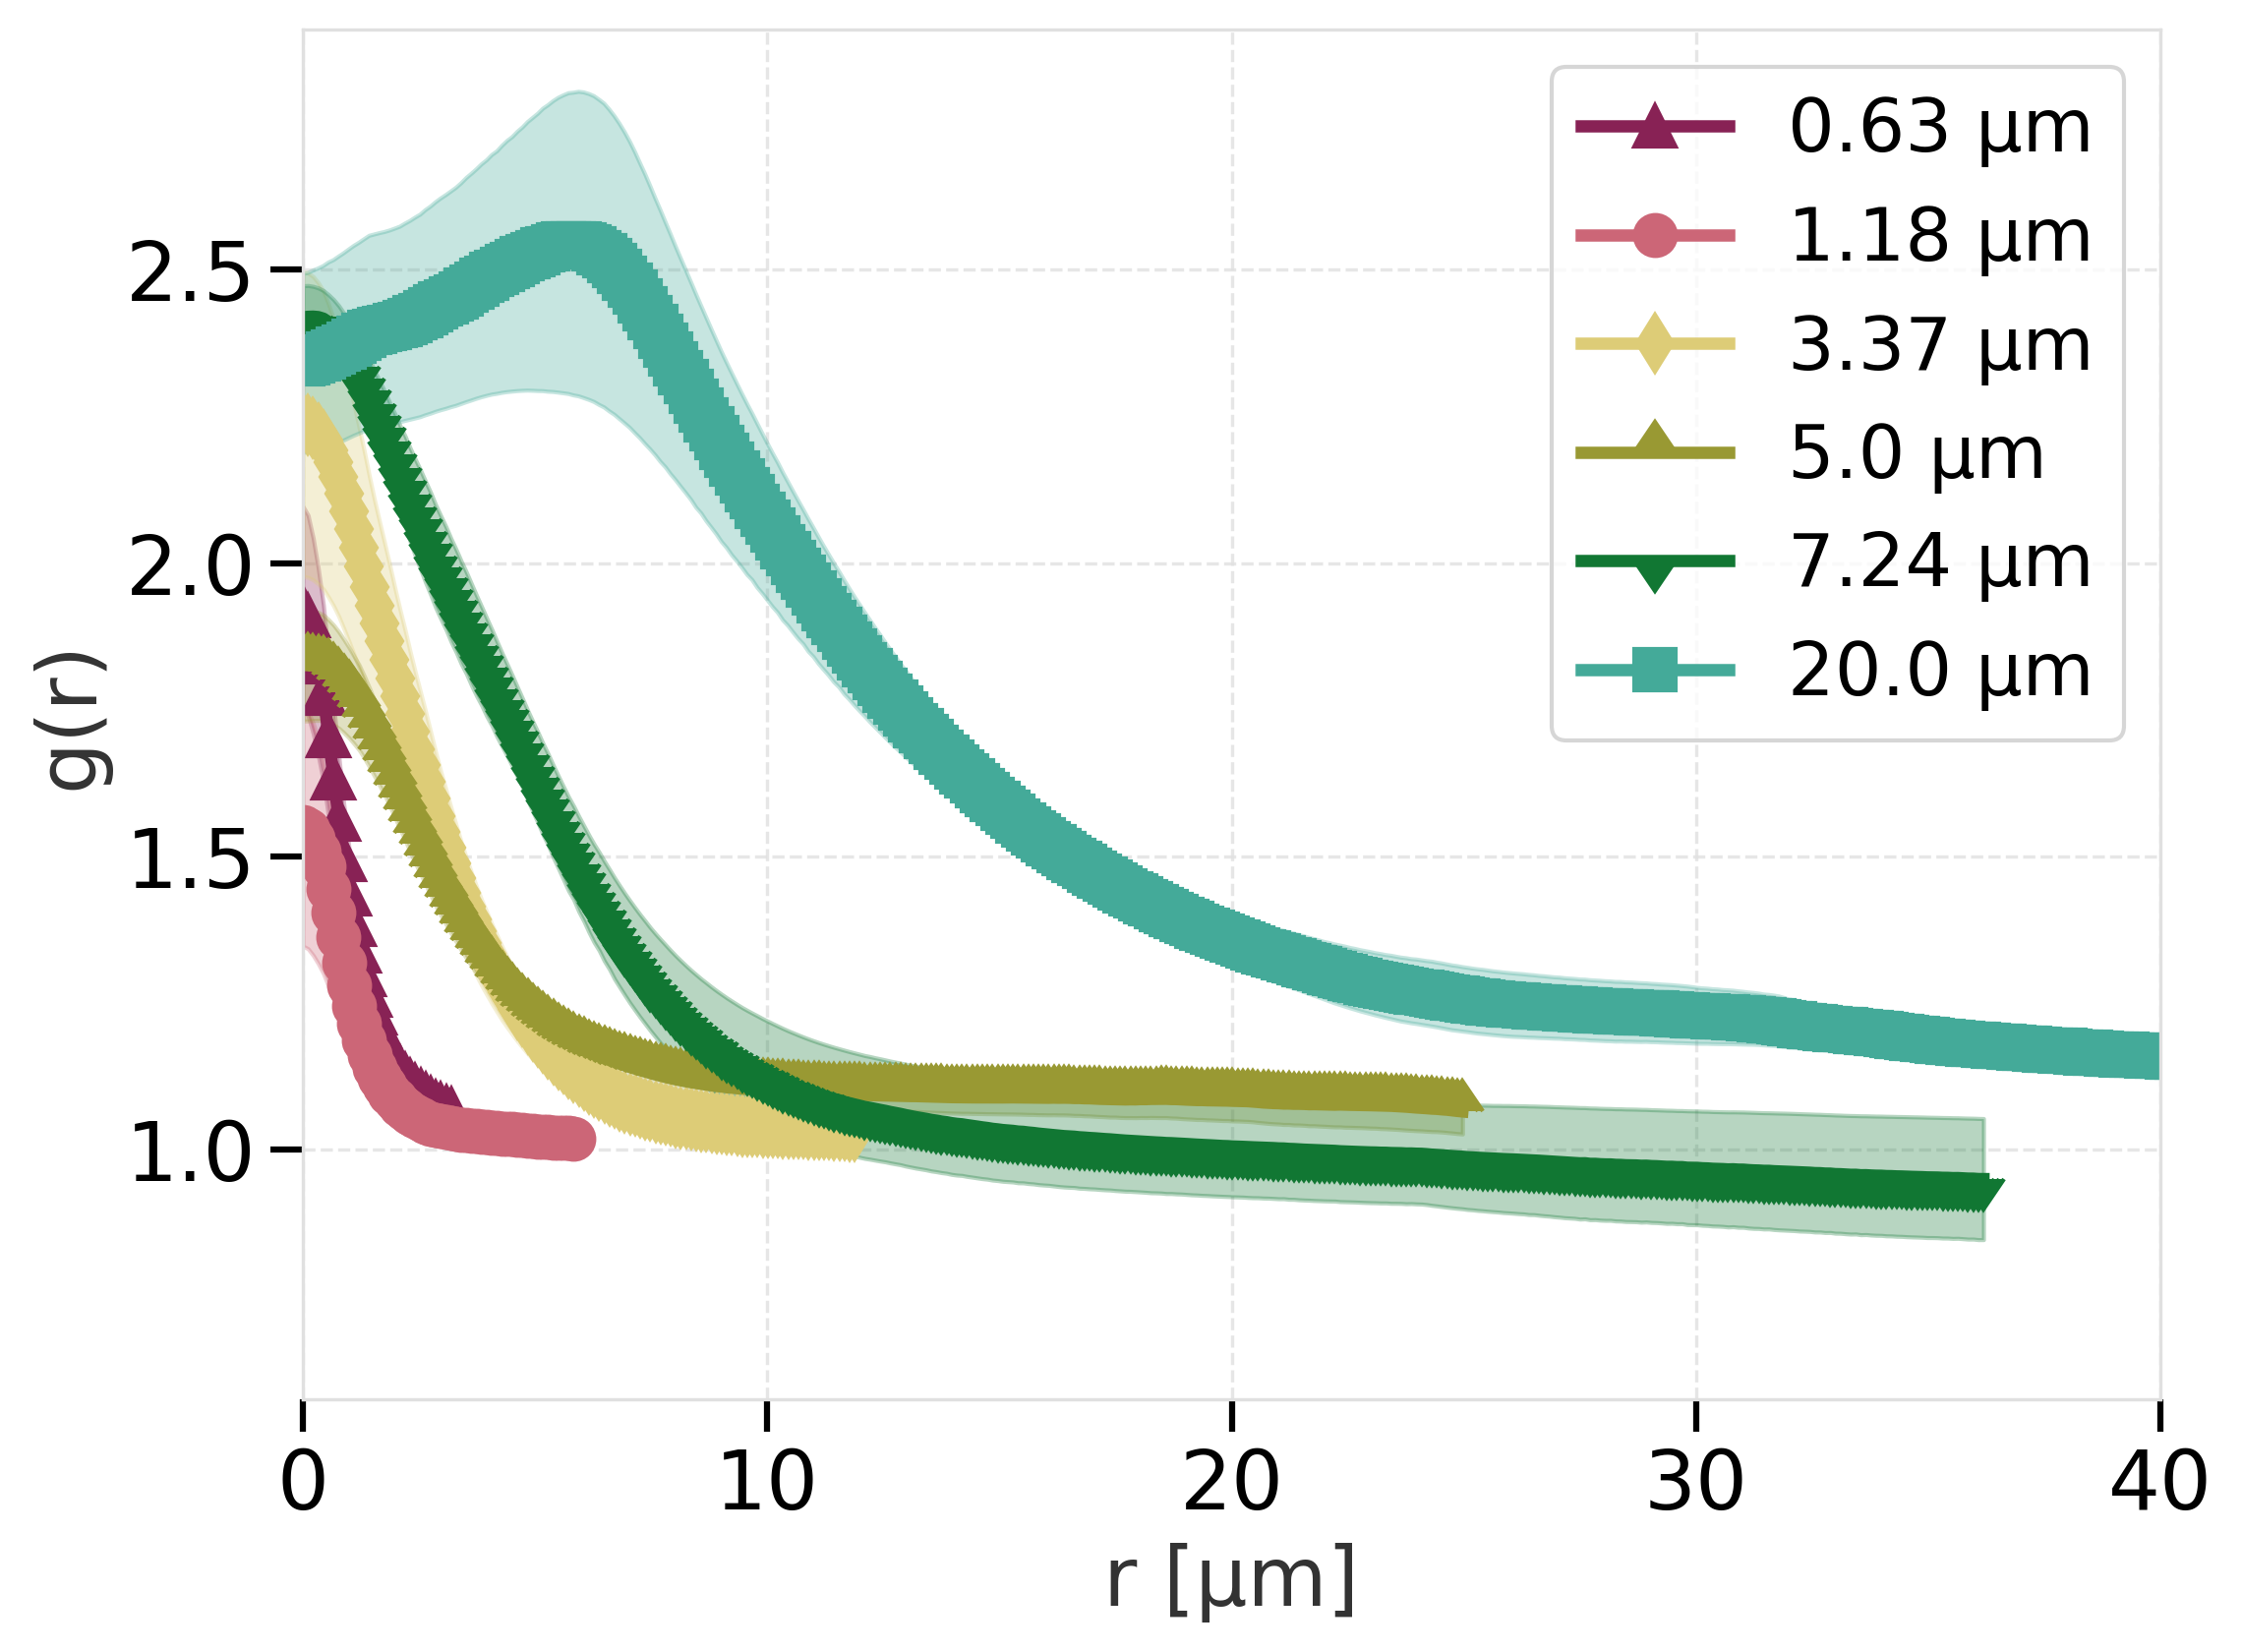

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

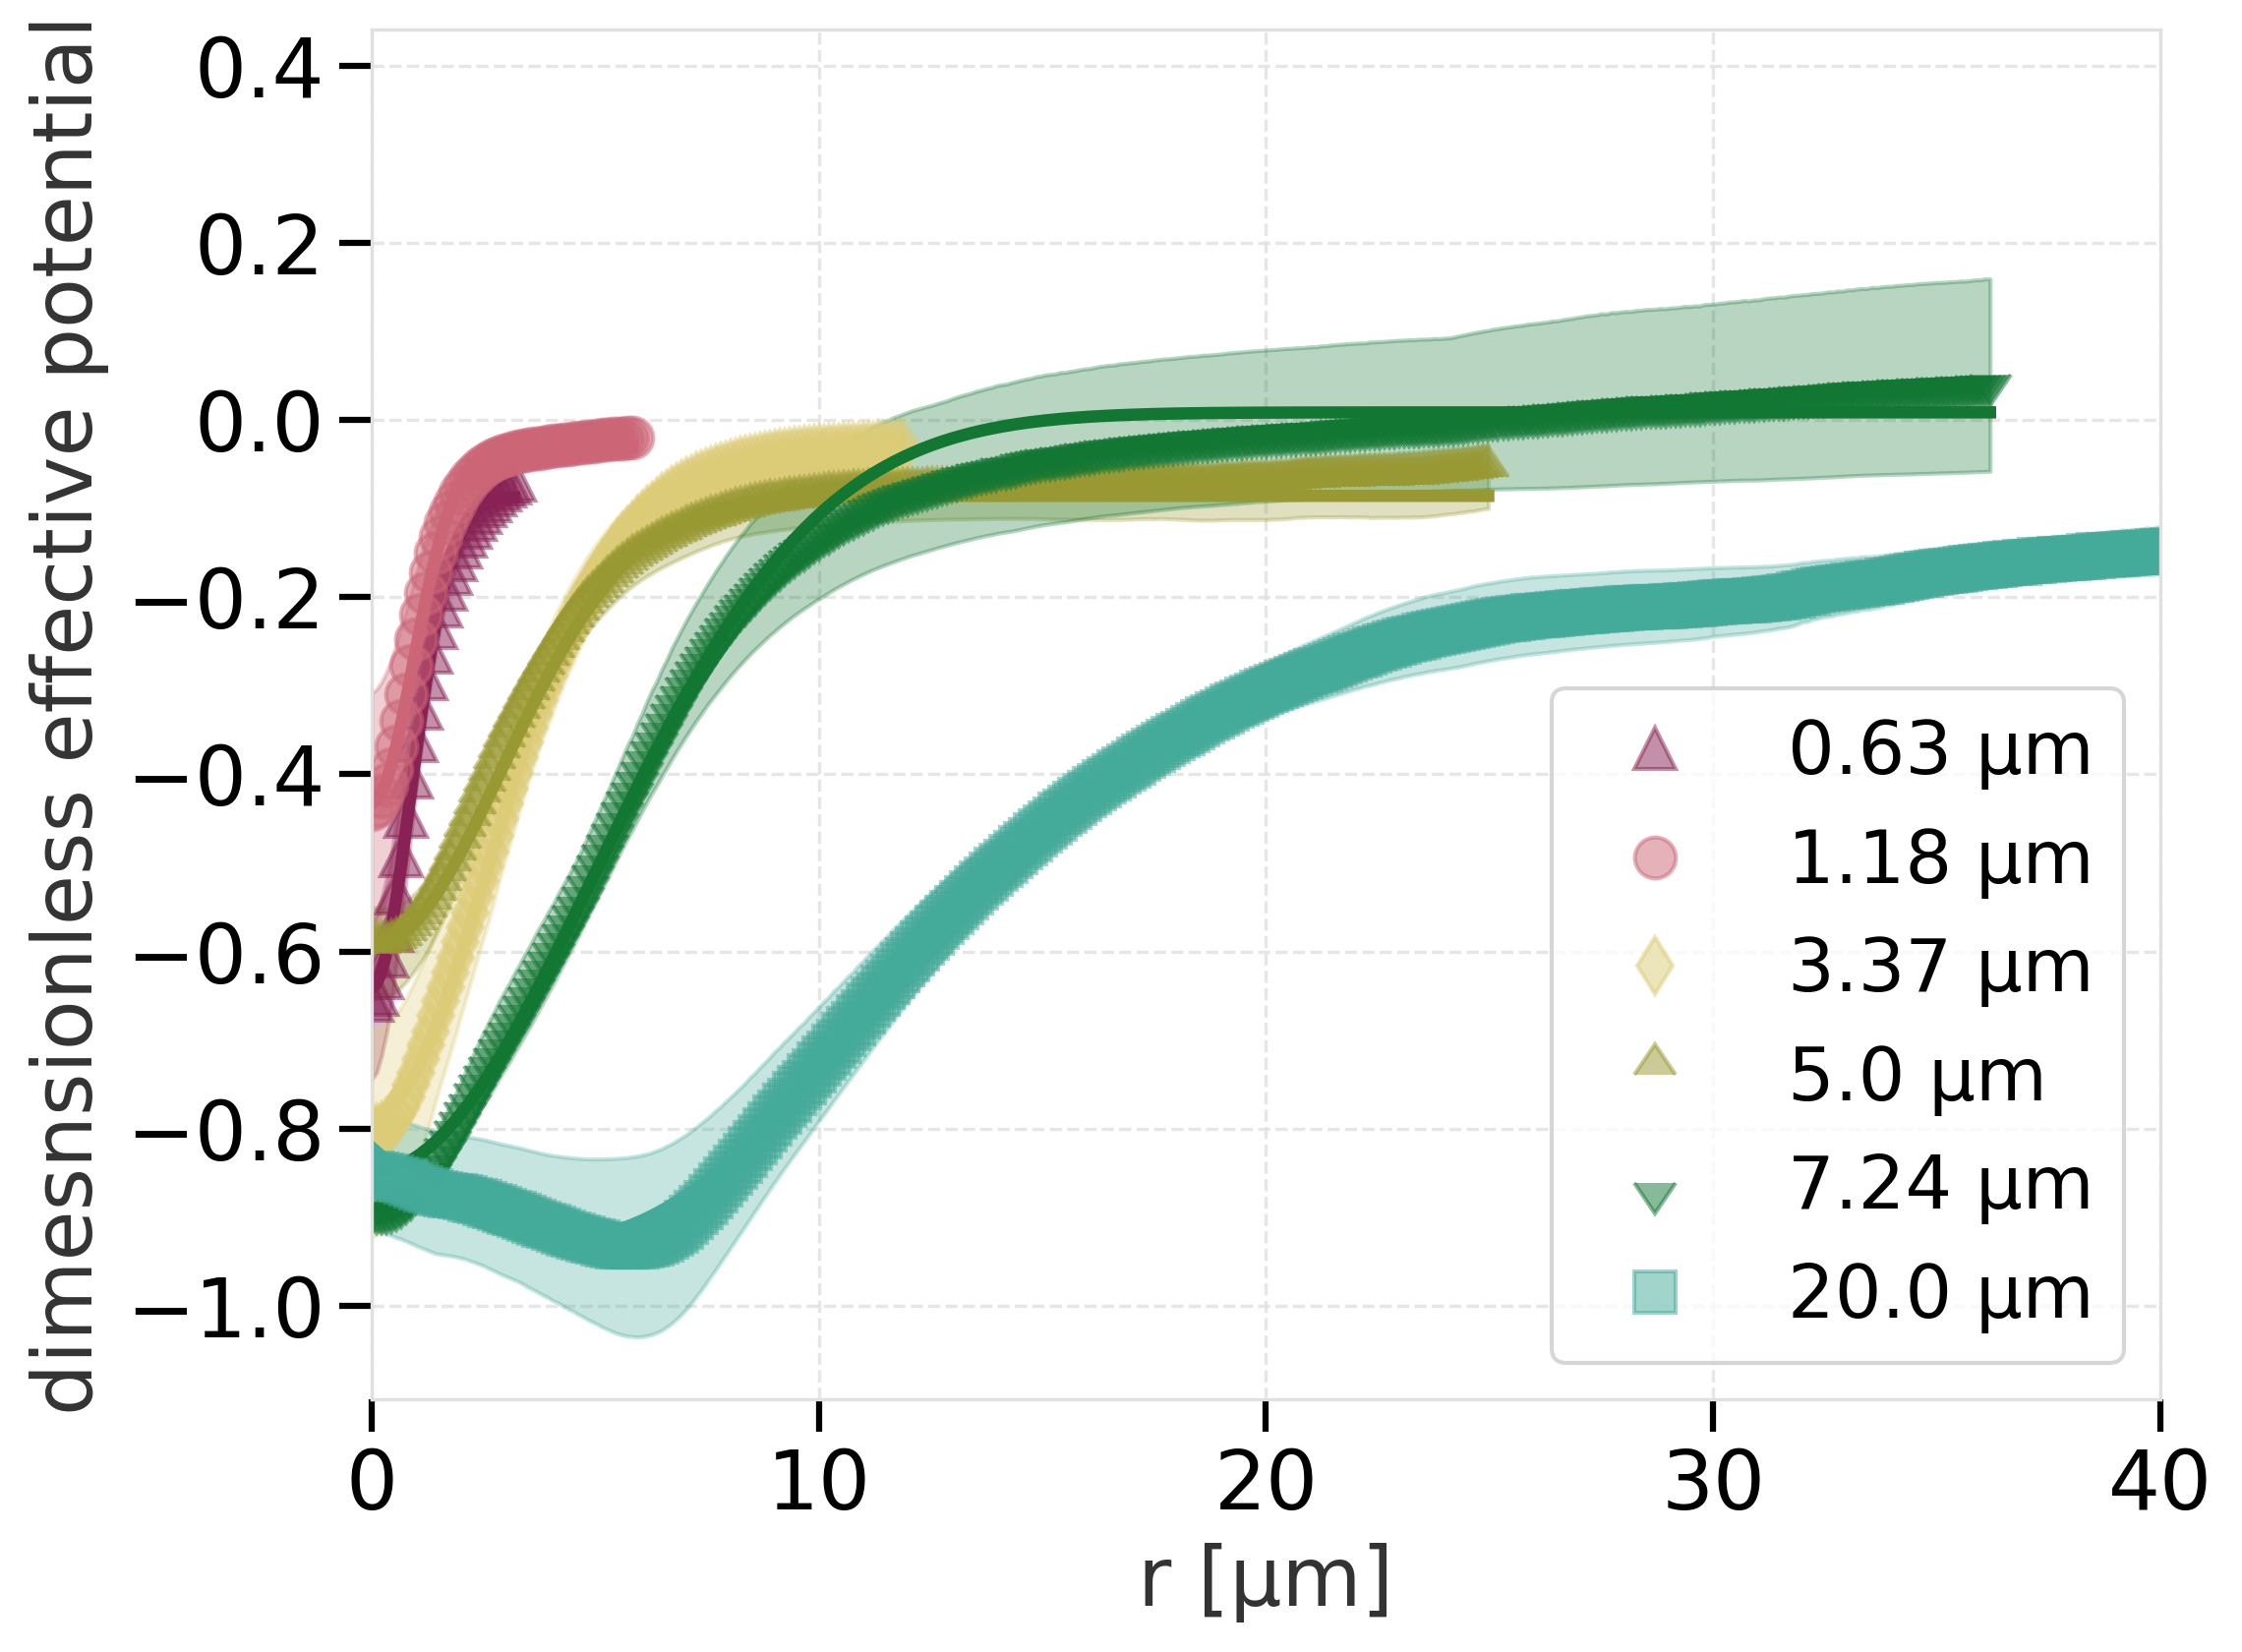

In [ ]:
import zarr
import glob
import numpy as np
import matplotlib.pyplot as plt
import os
import argparse
from pathlib import Path
from scipy.optimize import curve_fit

root = Path("/Volumes/data/Sasaki/MTsingleBeads")
root = Path("/mnt/NAS-Ebanaru/Sasaki/MTsingleBeads")

beads = [
        (0.63, root / "beads06um/*/*", "C0", "^", 0, 40),
        (1.18, root/"beads1um/*/*", "C1", "o", 0, 40),
        (3.37, root/"beads3um/*/*", "C2", "d", 0, 40),
        (5.0, root/"beads5um/*/*", "C3", 10, 0, 40),
        (7.24, root/"beads7um/*/*", "C4", 11, 0, 40),
        (20.0, root/"beads20um/*/*", "C5", "s", 0, 30),
    ]

def ring_gaussian(r, A, H, r_0, w):
    return A - H * np.exp(- (r - r_0)**2 / (2.0 * w**2))

def get_experiment_rdfs(base_path):
    """
    指定されたパスパターンにマッチする各ディレクトリのRDFを読み込み、
    実験（ディレクトリ）ごとの平均RDFのリストを返す。
    """
    dirs = glob.glob(str(base_path))
    exp_means = []
    
    for d in dirs:
        zarr_path = os.path.join(d, "RDF.zarr")
        # RDF.zarr が存在するものだけをロード
        if os.path.exists(zarr_path):
            print(f"Loading: {zarr_path}")
            rdf = zarr.open_array(zarr_path, mode='r')[:]
            if len(rdf) > 0:
                # このディレクトリ内の全フレーム・粒子の平均を計算し、1つの実験データとする
                exp_means.append(np.nanmean(rdf, axis=0))
                
    return np.array(exp_means)

def calc_potential(base_path, scale=0.11):
    exp_means = get_experiment_rdfs(base_path)
    
    if len(exp_means) > 0:
        max_r = exp_means.shape[1]
        r = np.arange(max_r) * scale
        
        # 実験間の平均と標準誤差を計算
        rdf_mean = np.nanmean(exp_means, axis=0)
        rdf_sem = np.nanstd(exp_means, axis=0) / np.sqrt(len(exp_means))
        
        # ポテンシャルと、誤差伝播を用いたポテンシャルの標準誤差を計算
        # U(r) = -ln(g(r))
        # 誤差 dU = dg / g
        with np.errstate(divide='ignore', invalid='ignore'):
            potential_mean = -np.log(rdf_mean)
            potential_sem = rdf_sem / rdf_mean
            potential_exps = -np.log(exp_means)
            
        return r, rdf_mean, rdf_sem, potential_mean, potential_sem, potential_exps
    else:
        print(f"有効な RDF.zarr が見つかりませんでした: {base_path}")
        return None

plt.style.use('../libs/my_style.mplstyle')

fig_rdf, ax_rdf = plt.subplots()
fig_pot, ax_pot = plt.subplots()

popts_list = []

for diameter, path, color, marker, min_fit, max_fit in beads:
    res = calc_potential(path)
    if res is None:
        continue
    r, rdf_mean, rdf_sem, potential_mean, potential_sem, potential_exps = res

    ax_rdf.plot(r, rdf_mean, label=f'{diameter} μm', color=color, marker=marker)
    ax_rdf.fill_between(r, rdf_mean - rdf_sem, rdf_mean + rdf_sem, color=color, alpha=0.3)

    ax_pot.plot(r, potential_mean, label=f'{diameter} μm', color=color, marker=marker, linestyle='None', alpha=0.5)
    ax_pot.fill_between(r, potential_mean - potential_sem, potential_mean + potential_sem, color=color, alpha=0.3)

    indices = np.where((min_fit <= r) & (r<=max_fit))    
    
    valid_mean = np.isfinite(potential_mean[indices])
    if np.sum(valid_mean) > 0:
        try:
            popt_pot_mean, pcov_pot_mean = curve_fit(ring_gaussian, r[indices][valid_mean], potential_mean[indices][valid_mean], maxfev = 10000, bounds = ([-1, 0, 0, 0], [np.inf, np.inf, np.inf, np.inf]))
            ax_pot.plot(r[indices], ring_gaussian(r[indices], *popt_pot_mean), color=color)
        except RuntimeError:
            pass
            
    for pot_exp in potential_exps:
        valid = np.isfinite(pot_exp[indices])
        if np.sum(valid) > 0:
            try:
                popt_pot, pcov_pot = curve_fit(ring_gaussian, r[indices][valid], pot_exp[indices][valid], maxfev = 10000, bounds = ([-1, 0, 0, 0], [np.inf, np.inf, np.inf, np.inf]))
                popt_insert_d = np.insert(popt_pot, 0, diameter)
                popts_list.append(popt_insert_d)
            except RuntimeError:
                pass

ax_rdf.set_xlabel('r [μm]')
ax_rdf.set_ylabel('g(r)')
ax_rdf.set_xlim((0,40))
ax_rdf.legend()

ax_pot.set_xlabel('r [μm]')
ax_pot.set_ylabel('dimesnsionless effective potential')
ax_pot.set_xlim((0,40))
ax_pot.legend()

fig_rdf.savefig(root/'figure/rdf.svg')
fig_pot.savefig(root/'figure/d_less_potential.svg')

popts = np.array(popts_list) # diameter, A, H, r_0, w
popts_T = popts.T


[Text(0.5, 0, 'diameter [μm]'), Text(0, 0.5, '$r_0$ [μm]')]

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

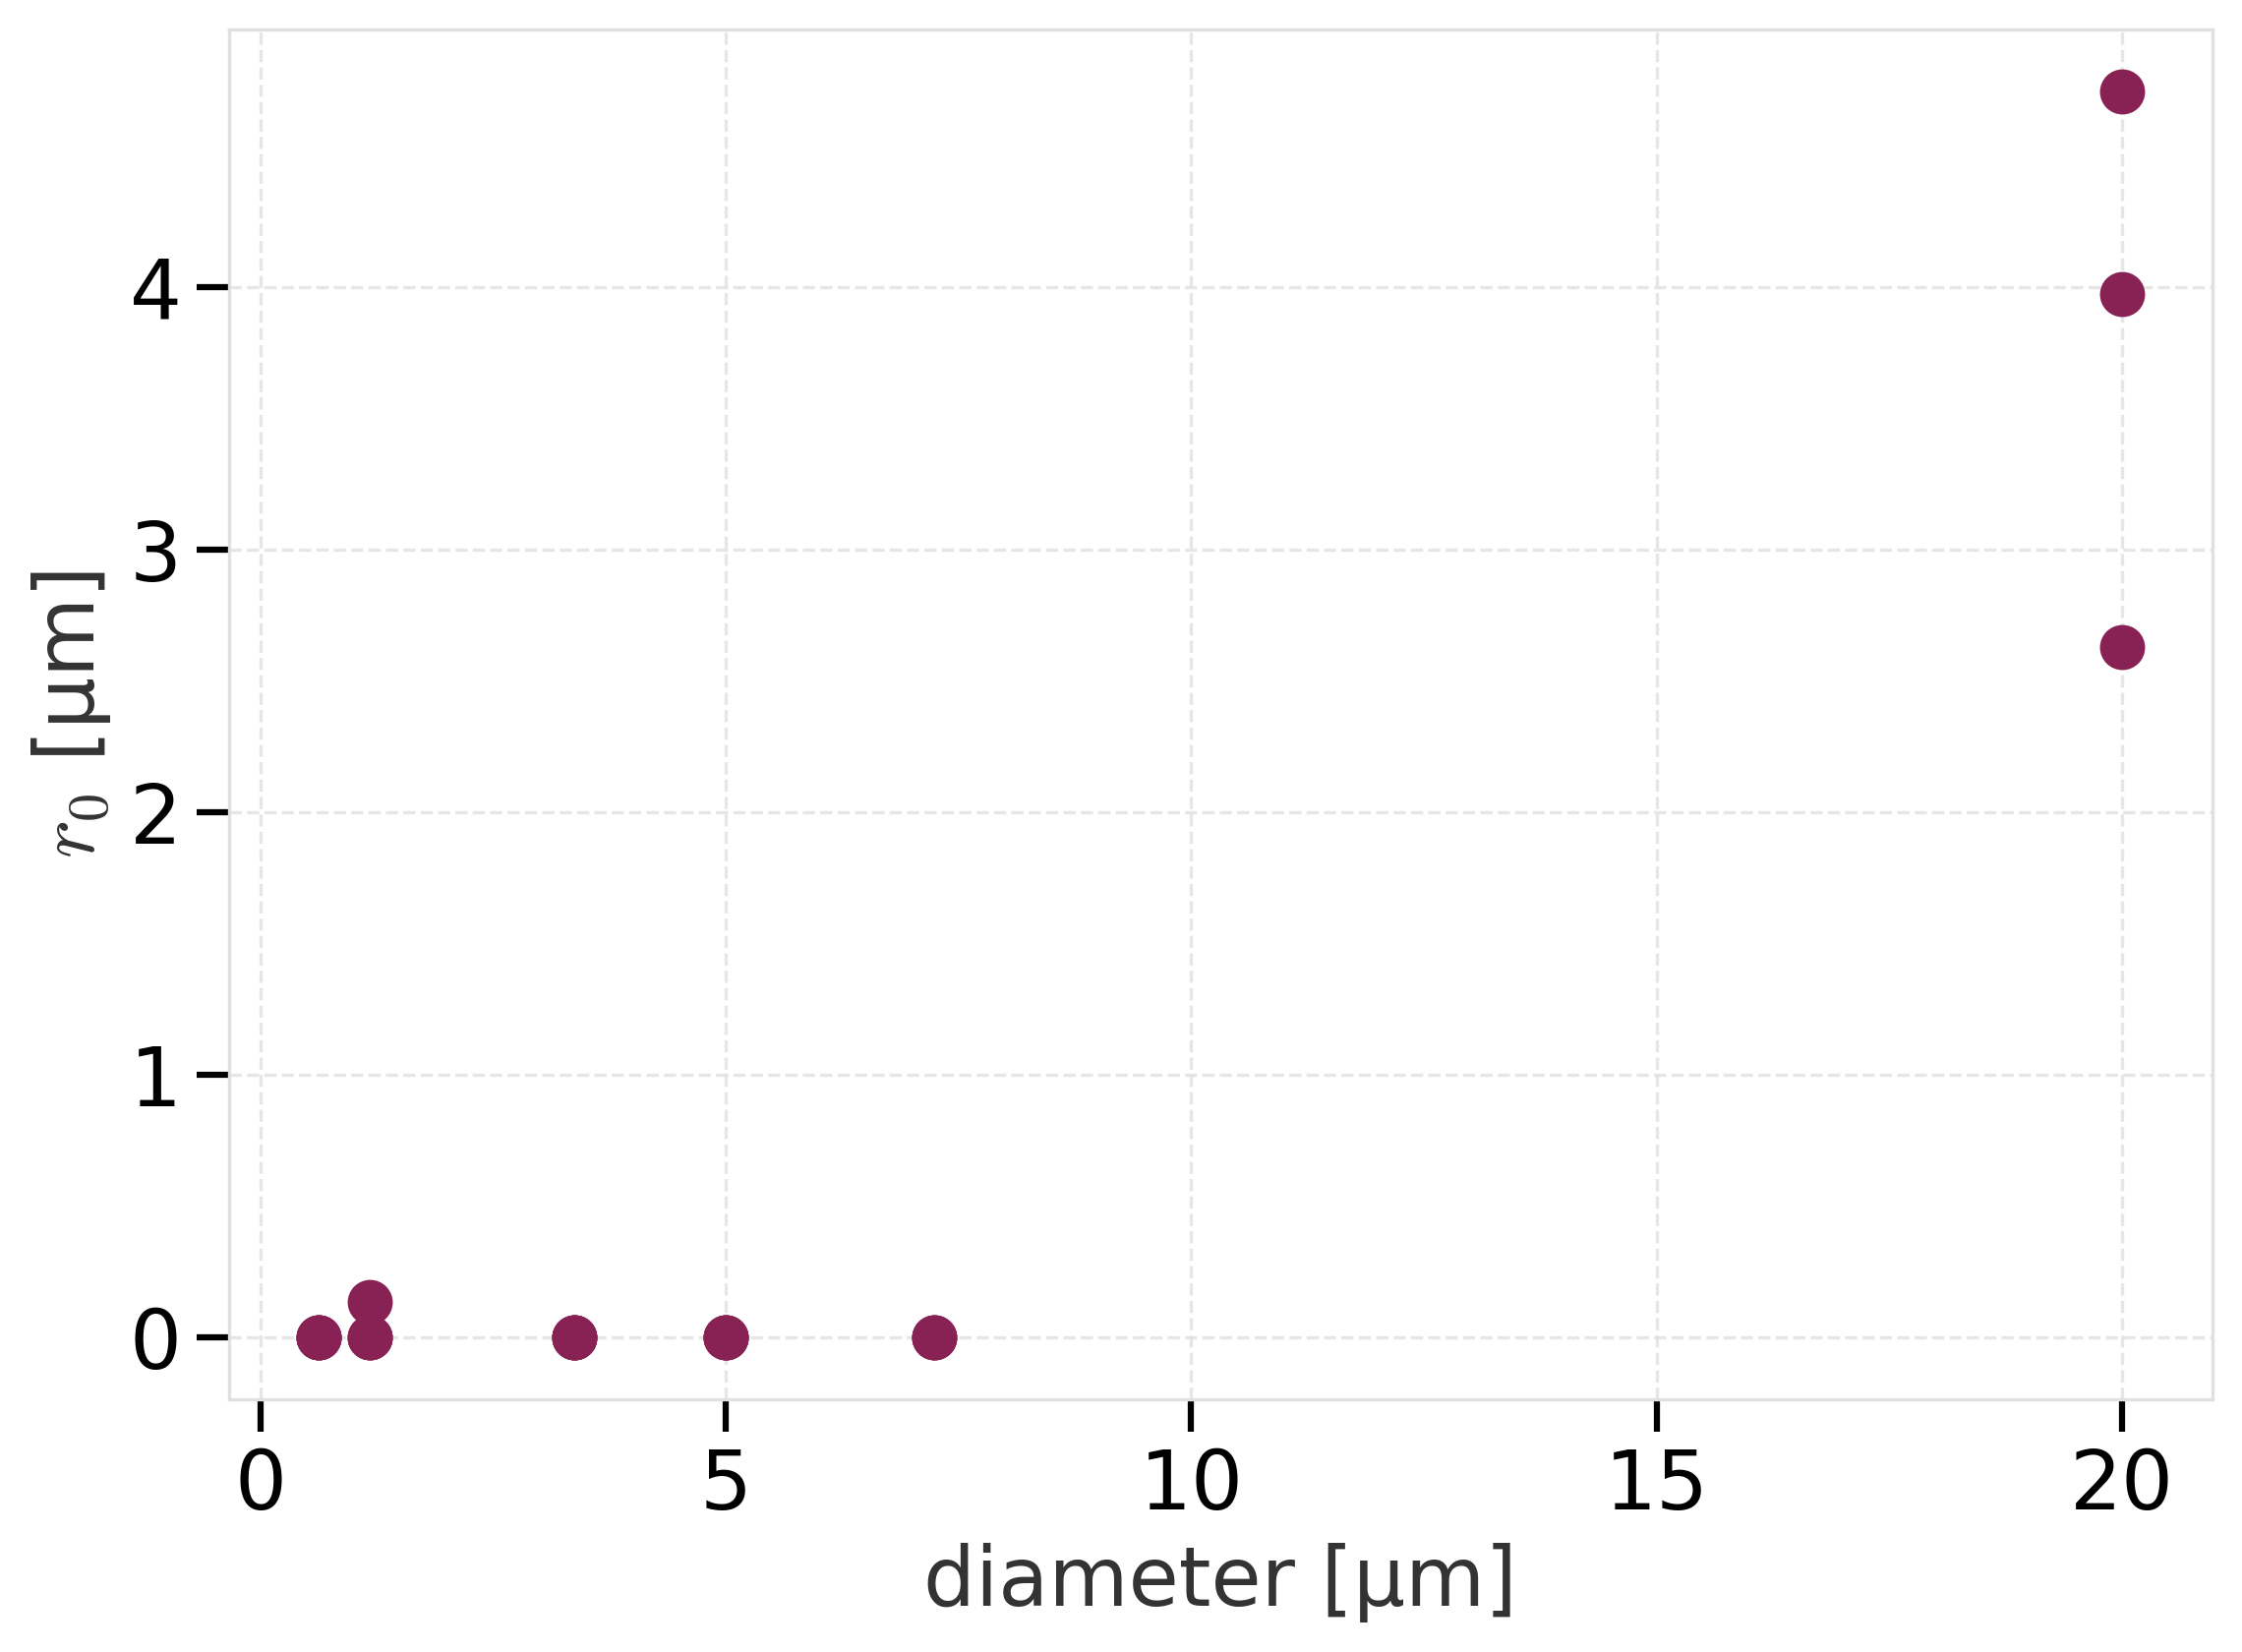

In [41]:
fig, ax = plt.subplots()
ax.scatter(popts_T[0], popts_T[3], marker = 'o')

ax.set(xlabel = "diameter [μm]",
       ylabel = '$r_0$ [μm]')


[Text(0.5, 0, 'diameter [μm]'), Text(0, 0.5, '$w$ [μm]')]

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

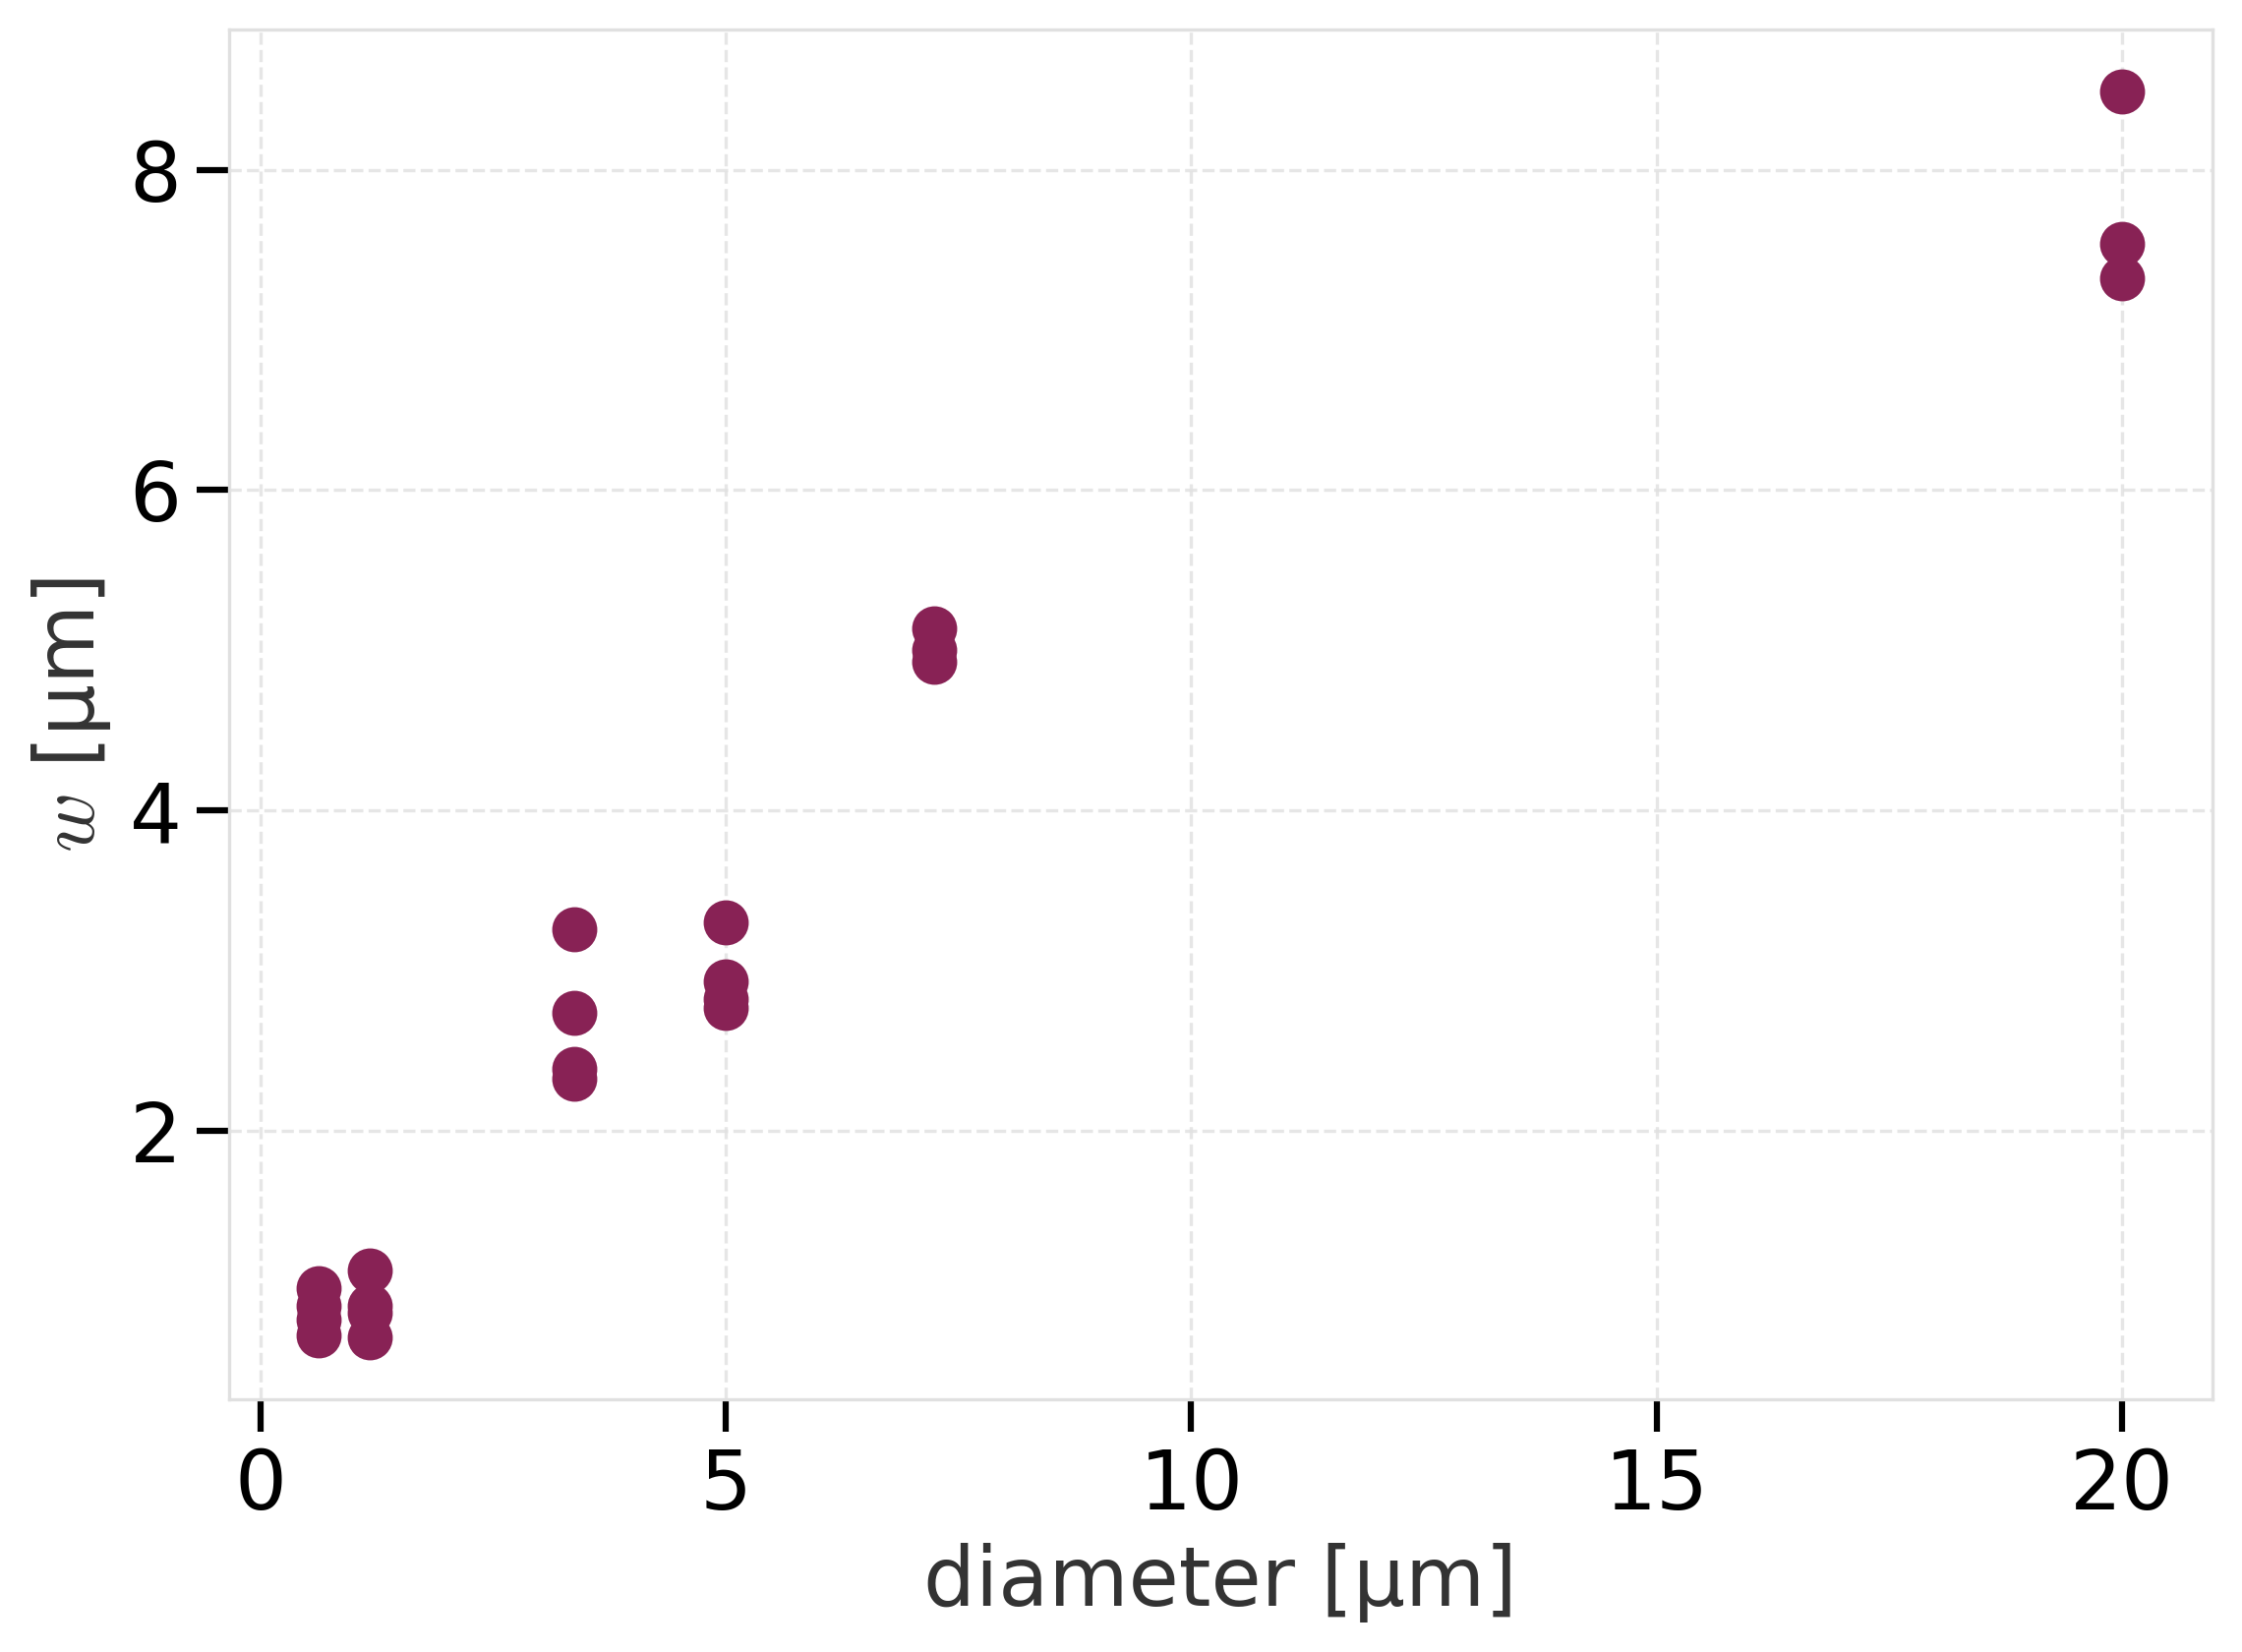

In [42]:
fig, ax = plt.subplots()
ax.scatter(popts_T[0], popts_T[4], marker='o')

ax.set(xlabel = "diameter [μm]",
       ylabel = '$w$ [μm]')
